 # DINO 학습 과정 워크스루

 **DINO** = self-**di**stillation with **no** labels ([Caron et al., ICCV 2021](https://arxiv.org/abs/2104.14294)).

 이 노트북은 `main_dino.py` 의 학습 파이프라인을 **실제 저장소 코드를 그대로 import 해서**
 한 조각씩 실행해 보며 이해하는 것을 목표로 한다. 재구현이 아니라 해부다.

 ## 한 문장 요약

 > 레이블도, negative pair도, contrastive loss도 없이 —
 > **같은 이미지의 서로 다른 crop 두 개를 같은 확률분포로 매핑하도록** 학생 네트워크를 학습시키고,
 > 교사는 학생의 EMA(exponential moving average)로만 갱신한다.

 이 설정은 자명한 해(모든 입력에 같은 값을 출력)로 붕괴(collapse)할 수 있고,
 DINO의 실질적 기여는 **그 붕괴를 centering + sharpening 두 힘의 균형으로 막는 것**이다.

 ## 목차

 | § | 내용 | 소스 |
 |---|---|---|
 | 1 | 환경 준비 | — |
 | 2 | 전체 목적함수 | `main_dino.py` |
 | 3 | 데이터: multi-crop 증강 | `DataAugmentationDINO` |
 | 4 | 모델: backbone + DINOHead | `vision_transformer.py` |
 | 5 | `MultiCropWrapper` 의 해상도 그룹핑 | `utils.py` |
 | 6 | `DINOLoss`: cross-entropy + centering + sharpening | `main_dino.py` |
 | 7 | 붕괴 방지 두 힘의 균형 (실험) | — |
 | 8 | 스케줄 4종 (lr / wd / momentum / teacher temp) | `utils.cosine_scheduler` |
 | 9 | EMA teacher 갱신 | `train_one_epoch` |
 | 10 | 학습 1 iteration 완전 해부 | `train_one_epoch` |
 | 11 | 미니 학습 루프 + 붕괴 진단 | — |
 | 12 | 표현 품질 확인: k-NN | `eval_knn.py` |
 | 13 | 어텐션은 왜 물체를 찾는가 | `visualize_attention.py` |
 | 14 | 요약 · 함정 · 다음 단계 | — |

 **전제**: 이 저장소 루트(또는 하위 디렉터리)에서 실행. GPU 없어도 동작하지만 §11 은 느리다.
 실제 실행 명령 모음은 [SAMPLES.md](../SAMPLES.md), 구조 분석은
 [docs/analysis/](../docs/analysis/) 를 참고.

 ## 1. 환경 준비

 `DINOLoss.update_center` 가 `dist.all_reduce` 를 호출하므로 **프로세스 그룹 초기화가 필수**다.
 노트북에서는 world_size=1 짜리 그룹을 직접 띄운다
 (`utils.init_distributed_mode` 는 GPU가 없으면 `sys.exit(1)` 이라 그대로 쓰지 않는다).

In [ ]:
import os, sys, math, time, json, warnings
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.distributed as dist
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="torch.nn.utils.weight_norm")

# ── 저장소 루트 찾아 sys.path 에 추가
REPO = Path.cwd().resolve()
while not (REPO / "main_dino.py").exists() and REPO != REPO.parent:
    REPO = REPO.parent
assert (REPO / "main_dino.py").exists(), "dino 저장소 안에서 실행하세요"
sys.path.insert(0, str(REPO))

import utils
import vision_transformer as vits
from vision_transformer import DINOHead
from main_dino import DINOLoss, DataAugmentationDINO

# ── world_size=1 프로세스 그룹 (centering 의 all_reduce 를 위해)
if not dist.is_available():
    raise RuntimeError("torch.distributed 가 없으면 DINOLoss 를 그대로 쓸 수 없습니다")
if not dist.is_initialized():
    os.environ.setdefault("MASTER_ADDR", "127.0.0.1")
    os.environ.setdefault("MASTER_PORT", "29517")
    backend = "nccl" if torch.cuda.is_available() else "gloo"
    dist.init_process_group(backend, rank=0, world_size=1)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
utils.fix_random_seeds(0)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.unicode_minus": False})

# ── 그래프 한글 라벨용 폰트 (없으면 네모로 보이므로 경고만)
from matplotlib import font_manager
_avail = {f.name for f in font_manager.fontManager.ttflist}
_ko = next((f for f in ["NanumGothic", "Noto Sans CJK KR", "Noto Sans CJK JP",
                        "Malgun Gothic", "AppleGothic", "UnDotum"] if f in _avail), None)
if _ko:
    plt.rcParams["font.family"] = [_ko, "DejaVu Sans"]
else:
    print("! 한글 폰트를 찾지 못했습니다 — 그래프 라벨이 네모로 보일 수 있습니다")

print(f"repo    : {REPO}")
print(f"torch   : {torch.__version__}  device={DEVICE}")
print(f"backend : {dist.get_backend()}  world_size={dist.get_world_size()}")

repo    : /home/sungwoo/projects/swcho/dino
torch   : 2.4.0+cu121  device=cuda
backend : nccl  world_size=1


 ## 2. 전체 목적함수

 학생 $g_{\theta_s}$ 와 교사 $g_{\theta_t}$ 는 **구조가 완전히 같다**. 다른 것은 파라미터뿐이다.

 한 이미지 $x$ 에서 만든 view 집합을

 $$
 V = \underbrace{\{x_1^{g},\, x_2^{g}\}}_{V^{g}\ (224\text{px, global})}\ \cup\ \underbrace{\{x_1^{l},\dots,x_{N}^{l}\}}_{96\text{px, local},\ N=8}
 $$

 라 하면, 최소화하는 목적은

 $$
 \min_{\theta_s}\ \mathbb{E}_{x\sim\mathcal{D}}
 \left[\ \frac{1}{|\mathcal{N}|}\sum_{u\in V^{g}}\ \sum_{\substack{v\in V\\ v\neq u}}
 H\big(P_{\theta_t}(u),\, P_{\theta_s}(v)\big)\right],
 \qquad H(a,b) = -\sum_{k} a_k \log b_k
 $$

 여기서 핵심 비대칭 세 가지:

 1. **교사는 global view만 본다** ($u \in V^g$), 학생은 전부 본다 ($v \in V$)
    → *"작은 조각을 보고 전체를 예측"* 하는 local-to-global 대응이 강제된다.
 2. **$v = u$ 인 쌍은 제외** → 같은 view끼리 맞추는 자명한 항이 없다.
 3. **교사에는 gradient가 흐르지 않는다**. 교사는 오직

 $$
 \theta_t \leftarrow m\,\theta_t + (1-m)\,\theta_s
 $$

 로만 갱신된다 (momentum encoder). $\mathcal{N}$ 은 항의 개수 $= 2(2+N) - 2$.

 $N=8$ 이면 $|\mathcal{N}| = 18$ 개 항이 한 이미지마다 만들어진다.

 ## 3. 데이터: multi-crop 증강

 `DataAugmentationDINO.__call__` 은 이미지 하나에서 **텐서 리스트**를 만든다
 (길이 $2+N$). 레이블은 `ImageFolder` 가 읽지만 `train_one_epoch` 에서
 `for it, (images, _) in ...` 로 **버려진다** — 클래스 디렉터리가 하나뿐이어도 학습은 돈다.

 | crop | 해상도 | `scale` | 특이 증강 |
 |---|---|---|---|
 | global 1 | 224 | $(0.4, 1.0)$ | GaussianBlur $p{=}1.0$ |
 | global 2 | 224 | $(0.4, 1.0)$ | GaussianBlur $p{=}0.1$ + Solarization $p{=}0.2$ |
 | local × 8 | 96 | $(0.05, 0.4)$ | GaussianBlur $p{=}0.5$ |

 `RandomResizedCrop` 의 `scale` 은 **원본 면적 대비 비율**이다. local의 상한 $0.4$ 가
 global의 하한 $0.4$ 와 맞닿아 있어 **local crop은 항상 global 이하의 영역**을 본다.

 두 global crop이 blur 확률과 solarize 유무에서 서로 다른 것(BYOL에서 온 설계)도 의도적이다:
 두 view의 저수준 통계를 다르게 만들어, 색·주파수 같은 단서로 쉽게 매칭되는 지름길을 막는다.

In [ ]:
from PIL import Image
from torchvision import datasets, transforms

# ── 스모크용 소형 데이터셋 확보 (없으면 합성 데이터 생성; 다운로드 없음)
CANDIDATES = [REPO / "out/dino_cifar", REPO / "out/dino_tiny"]
DATA_ROOT = next((p for p in CANDIDATES if (p / "train").exists()), None)
if DATA_ROOT is None:
    DATA_ROOT = REPO / "out/dino_tiny"
    print("데이터셋 생성 중 ...")
    os.system(f"{sys.executable} {REPO}/samples/make_tiny_dataset.py "
              f"--out {DATA_ROOT} --source synth")
print("DATA_ROOT =", DATA_ROOT)

transform = DataAugmentationDINO(
    global_crops_scale=(0.4, 1.0),
    local_crops_scale=(0.05, 0.4),
    local_crops_number=8,
)
dataset = datasets.ImageFolder(str(DATA_ROOT / "train"), transform=transform)
print(f"images={len(dataset)}  classes={len(dataset.classes)}")

# ── crop 한 세트 만들어 보기
raw_path = REPO / "out/dino_attn/img.png"
raw = Image.open(raw_path).convert("RGB") if raw_path.exists() else \
      Image.open(dataset.samples[0][0]).convert("RGB")
crops = transform(raw)

print(f"\ncrop 개수: {len(crops)}")
for i, c in enumerate(crops):
    tag = "global" if i < 2 else "local "
    print(f"  [{i:2d}] {tag}  shape={tuple(c.shape)}")

DATA_ROOT = /home/sungwoo/projects/swcho/dino/out/dino_cifar
images=600  classes=10

crop 개수: 10
  [ 0] global  shape=(3, 224, 224)
  [ 1] global  shape=(3, 224, 224)
  [ 2] local   shape=(3, 96, 96)
  [ 3] local   shape=(3, 96, 96)
  [ 4] local   shape=(3, 96, 96)
  [ 5] local   shape=(3, 96, 96)
  [ 6] local   shape=(3, 96, 96)
  [ 7] local   shape=(3, 96, 96)
  [ 8] local   shape=(3, 96, 96)
  [ 9] local   shape=(3, 96, 96)


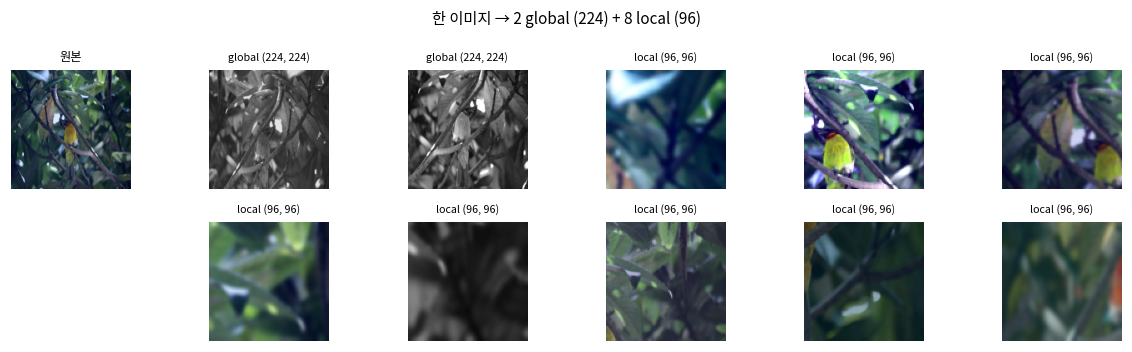

In [ ]:
MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def denorm(t):
    return (t.cpu() * STD + MEAN).clamp(0, 1).permute(1, 2, 0).numpy()

fig = plt.figure(figsize=(11, 3.2))
ax = fig.add_subplot(2, 6, 1)
ax.imshow(raw.resize((224, 224))); ax.set_title("원본", fontsize=8); ax.axis("off")
for i, c in enumerate(crops):
    ax = fig.add_subplot(2, 6, i + 2 if i < 5 else i + 3)
    ax.imshow(denorm(c))
    ax.set_title(("global" if i < 2 else "local") + f" {tuple(c.shape[-2:])}", fontsize=7)
    ax.axis("off")
fig.suptitle("한 이미지 → 2 global (224) + 8 local (96)", fontsize=10)
fig.tight_layout(); plt.show()

 > **암묵적 계약**: `crops` 리스트는 **해상도별로 연속 정렬**되어 있어야 한다 (global 2개 먼저).
 > §5 의 `MultiCropWrapper` 가 `torch.unique_consecutive` 로 그룹을 잡기 때문이다.
 > 증강 순서를 섞으면 에러 없이 조용히 backbone forward 횟수만 늘어난다.

 ## 4. 모델: backbone + DINOHead

 $$
 g_\theta = h_\theta \circ f_\theta
 $$

 - $f_\theta$ : **backbone** (ViT). 출력은 CLS 토큰 $\in \mathbb{R}^{D}$
 - $h_\theta$ : **DINOHead** (3-layer MLP → L2 정규화 → weight-norm 선형층)

 $$
 h_\theta(y) \;=\; W\,\tilde{u},
 \qquad \tilde{u} = \frac{\mathrm{MLP}(y)}{\lVert \mathrm{MLP}(y)\rVert_2} \in \mathbb{S}^{255}
 $$

 `nn.utils.weight_norm` 은 $W$ 의 각 행을 $w_k = g_k \dfrac{v_k}{\lVert v_k\rVert}$ 로 재매개화하는데,
 DINO는 `weight_g.data.fill_(1)` 로 $g_k = 1$ 을 넣고 `norm_last_layer=True` 면
 `requires_grad = False` 로 **고정**한다. 따라서 출력 로짓은

 $$
 z_k = \frac{v_k^{\top}\tilde u}{\lVert v_k \rVert} = \cos\angle(v_k,\ \tilde u) \in [-1, 1]
 $$

 즉 **$K$ 개 프로토타입 방향과의 코사인 유사도**다. 로짓의 스케일이 구조적으로 묶여 있어
 학습 초기에 한 프로토타입의 노름이 폭주하는 것을 막는다 — 이것이 붕괴 방지 장치의 0번째 요소다.

 기본값 $K = $ `out_dim` $= 65536$. 이 노트북은 가볍게 보려고 $K = 4096$ 을 쓴다.

In [ ]:
ARCH, PATCH, OUT_DIM = "vit_tiny", 16, 4096

def build_pair(arch=ARCH, patch_size=PATCH, out_dim=OUT_DIM, drop_path_rate=0.1):
    # main_dino.train_dino 의 모델 구성 부분과 동일 (DDP 제외)
    student_bb = vits.__dict__[arch](patch_size=patch_size, drop_path_rate=drop_path_rate)
    teacher_bb = vits.__dict__[arch](patch_size=patch_size)
    embed_dim = student_bb.embed_dim

    student = utils.MultiCropWrapper(
        student_bb, DINOHead(embed_dim, out_dim, use_bn=False, norm_last_layer=True))
    teacher = utils.MultiCropWrapper(
        teacher_bb, DINOHead(embed_dim, out_dim, use_bn=False))
    student, teacher = student.to(DEVICE), teacher.to(DEVICE)

    teacher.load_state_dict(student.state_dict())   # 같은 가중치에서 출발
    for p in teacher.parameters():
        p.requires_grad = False                     # 교사는 backprop 없음
    return student, teacher, embed_dim

student, teacher, EMBED_DIM = build_pair()

def npar(m):
    return sum(p.numel() for p in m.parameters())

print(f"{ARCH}/{PATCH}  embed_dim={EMBED_DIM}  out_dim={OUT_DIM}\n")
print(f"  backbone      : {npar(student.backbone)/1e6:7.2f} M")
print(f"  DINOHead      : {npar(student.head)/1e6:7.2f} M"
      f"   (마지막 층만 256x{OUT_DIM} = {256*OUT_DIM/1e6:.2f} M)")
print(f"  student 합계  : {npar(student)/1e6:7.2f} M  (학습됨)")
print(f"  teacher 합계  : {npar(teacher)/1e6:7.2f} M  (requires_grad=False)")
print(f"\n  teacher 중 grad 필요: {sum(p.requires_grad for p in teacher.parameters())} 개")

vit_tiny/16  embed_dim=192  out_dim=4096

  backbone      :    5.52 M
  DINOHead      :    6.17 M   (마지막 층만 256x4096 = 1.05 M)
  student 합계  :   11.69 M  (학습됨)
  teacher 합계  :   11.69 M  (requires_grad=False)

  teacher 중 grad 필요: 0 개


 > **실전 함의**: 기본값 `out_dim=65536` 이면 ViT-S 기준 head가 **22.4M** 으로
 > backbone(21.7M)보다 크다. 그런데 **학습이 끝나면 head는 통째로 버린다**
 > (공개 가중치가 21M인 이유). VRAM 계획에는 반드시 포함해야 한다.

In [ ]:
# ── forward shape 추적 (224 입력 1장)
x = crops[0].unsqueeze(0).to(DEVICE)
bb = student.backbone
with torch.no_grad():
    tok = bb.prepare_tokens(x)
    print(f"input                 {tuple(x.shape)}")
    print(f"prepare_tokens        {tuple(tok.shape)}   # CLS 1 + 패치 {(224//PATCH)**2}")
    h = tok
    for blk in bb.blocks:
        h = blk(h)
    h = bb.norm(h)
    print(f"blocks x{len(bb.blocks)} + norm     {tuple(h.shape)}")
    cls = h[:, 0]
    print(f"CLS 토큰              {tuple(cls.shape)}   <- backbone 출력")
    u = student.head.mlp(cls)
    print(f"head.mlp              {tuple(u.shape)}")
    un = F.normalize(u, dim=-1, p=2)
    print(f"L2 normalize          {tuple(un.shape)}   norm={un.norm(dim=-1).item():.4f}")
    z = student.head.last_layer(un)
    print(f"last_layer (로짓)     {tuple(z.shape)}   min={z.min():.3f} max={z.max():.3f}")

# 로짓이 코사인 유사도 범위에 갇혀 있는지 확인
assert z.abs().max() <= 1.0 + 1e-4, "norm_last_layer 가 깨졌다"
print("\n로짓이 [-1, 1] 안 → 프로토타입 코사인 유사도로 해석 가능 ✔")

# 어텐션 / linear probe 용 보조 경로
with torch.no_grad():
    attn = bb.get_last_selfattention(x)
    inter = bb.get_intermediate_layers(x, n=4)
print(f"\nget_last_selfattention   {tuple(attn.shape)}   # (B, heads, N, N)")
print(f"get_intermediate_layers  {len(inter)} x {tuple(inter[0].shape)}  -> linear probe")

input                 (1, 3, 224, 224)
prepare_tokens        (1, 197, 192)   # CLS 1 + 패치 196
blocks x12 + norm     (1, 197, 192)
CLS 토큰              (1, 192)   <- backbone 출력
head.mlp              (1, 256)
L2 normalize          (1, 256)   norm=1.0000
last_layer (로짓)     (1, 4096)   min=-0.229 max=0.223

로짓이 [-1, 1] 안 → 프로토타입 코사인 유사도로 해석 가능 ✔

get_last_selfattention   (1, 3, 197, 197)   # (B, heads, N, N)
get_intermediate_layers  4 x (1, 197, 192)  -> linear probe


 ## 5. `MultiCropWrapper`: 해상도 그룹핑

 crop 10개를 각각 forward하면 10번이지만, **해상도가 같은 것끼리 묶어 concat** 하면 2번이면 된다.

 ```python
 idx_crops = torch.cumsum(torch.unique_consecutive(
     torch.tensor([inp.shape[-1] for inp in x]), return_counts=True)[1], 0)
 ```

 `[224,224,96,96,96,96,96,96,96,96]` → counts `[2,8]` → cumsum `[2,10]`
 → backbone 호출 2회, 그 특징을 concat 한 뒤 head를 **한 번** 통과시킨다.

 `head` 를 마지막에 한 번만 부르는 것도 중요하다: head에 BatchNorm을 쓰는 경우
 (convnet 설정) 모든 crop의 통계가 함께 잡힌다.

In [ ]:
calls = []
hook = student.backbone.register_forward_pre_hook(
    lambda m, inp: calls.append(tuple(inp[0].shape)))

B = 4
batch = [c.unsqueeze(0).repeat(B, 1, 1, 1).to(DEVICE) for c in crops]
with torch.no_grad():
    out = student(batch)
hook.remove()

print(f"crop 해상도 리스트 : {[b.shape[-1] for b in batch]}")
print(f"backbone forward   : {len(calls)} 회  (crop 10개가 아니라!)")
for s in calls:
    print(f"    {s}")
print(f"\nstudent 출력       : {tuple(out.shape)}  = (2+8) x B={B} 행, 각 {OUT_DIM} 차원")

with torch.no_grad():
    t_out = teacher(batch[:2])          # 교사는 global 2개만
print(f"teacher 출력       : {tuple(t_out.shape)}  <- images[:2] 만 통과")

crop 해상도 리스트 : [224, 224, 96, 96, 96, 96, 96, 96, 96, 96]
backbone forward   : 2 회  (crop 10개가 아니라!)
    (8, 3, 224, 224)
    (32, 3, 96, 96)

student 출력       : (40, 4096)  = (2+8) x B=4 행, 각 4096 차원
teacher 출력       : (8, 4096)  <- images[:2] 만 통과


 ## 6. `DINOLoss`: cross-entropy + centering + sharpening

 ### 학생 분포

 $$
 P_s^{(v)}(k) = \frac{\exp\!\big(z_s^{(v)}(k)/\tau_s\big)}{\sum_{j=1}^{K}\exp\!\big(z_s^{(v)}(j)/\tau_s\big)},
 \qquad \tau_s = 0.1\ \text{(고정)}
 $$

 ### 교사 분포 — center 를 빼고, 더 낮은 온도로 sharpen

 $$
 P_t^{(u)}(k) = \frac{\exp\!\big((z_t^{(u)}(k) - c_k)/\tau_t\big)}{\sum_j \exp\!\big((z_t^{(u)}(j) - c_j)/\tau_t\big)},
 \qquad \tau_t : 0.04 \to \texttt{teacher\_temp}
 $$

 ### center 는 배치 평균의 EMA (모든 GPU에 걸쳐)

 $$
 c \;\leftarrow\; m_c\, c \;+\; (1 - m_c)\,\frac{1}{B\cdot W}\sum_{i=1}^{B\cdot W} z_t(i),
 \qquad m_c = 0.9
 $$

 $B \cdot W$ 의 $W$ 가 world_size다 — 그래서 `update_center` 안에 `dist.all_reduce` 가 있고,
 프로세스 그룹 없이는 `DINOLoss` 가 돌지 않는다.

 ### 최종 손실

 $$
 \mathcal{L} = \frac{1}{|\mathcal{N}|}\sum_{u \in \{1,2\}}\ \sum_{\substack{v=1 \\ v \neq u}}^{2+N}
 \Big(-\sum_{k=1}^{K} P_t^{(u)}(k)\,\log P_s^{(v)}(k)\Big),
 \qquad |\mathcal{N}| = 2(2+N) - 2
 $$

 `.detach()` 가 교사 분포에 걸려 있어 gradient는 학생 쪽으로만 흐른다.

In [ ]:
NEPOCHS = 3
dino_loss = DINOLoss(
    out_dim=OUT_DIM,
    ncrops=2 + 8,                      # local_crops_number + 2
    warmup_teacher_temp=0.04,
    teacher_temp=0.04,
    warmup_teacher_temp_epochs=0,
    nepochs=NEPOCHS,
    student_temp=0.1,
    center_momentum=0.9,
).to(DEVICE)

epoch = 0
loss = dino_loss(out, t_out, epoch)
print(f"loss = {loss.item():.4f}")
print(f"center: shape={tuple(dino_loss.center.shape)}  "
      f"norm={dino_loss.center.norm().item():.5f}  (첫 update 직후)")

# ── 수식대로 직접 계산해서 일치 확인
def dino_loss_manual(student_output, teacher_output, center, tau_s=0.1, tau_t=0.04, ncrops=10):
    s = (student_output / tau_s).chunk(ncrops)
    t = F.softmax((teacher_output - center) / tau_t, dim=-1).detach().chunk(2)
    total, n = 0.0, 0
    for iq, q in enumerate(t):
        for v in range(len(s)):
            if v == iq:
                continue                                   # 같은 view 쌍 제외
            total = total + (-q * F.log_softmax(s[v], dim=-1)).sum(-1).mean()
            n += 1
    return total / n, n

manual, n_terms = dino_loss_manual(out, t_out, torch.zeros(1, OUT_DIM, device=DEVICE))
print(f"\n직접 계산 loss = {manual.item():.4f}   항 개수 |N| = {n_terms}")
assert n_terms == 2 * (2 + 8) - 2 == 18
assert torch.allclose(manual, loss, atol=1e-4), "수식 재현 실패"
print("공식 구현과 일치 ✔   (center=0 인 첫 호출 기준)")

# ── 온도가 분포를 얼마나 날카롭게 만드는가
with torch.no_grad():
    p_t = F.softmax((t_out - dino_loss.center) / 0.04, dim=-1)
    p_s = F.softmax(out.chunk(2 + 8)[0] / 0.1, dim=-1)
    H = lambda p: -(p * p.clamp_min(1e-12).log()).sum(-1).mean().item()
print(f"\nlog K            = {math.log(OUT_DIM):.3f}  (완전 uniform 엔트로피)")
print(f"H(P_t)  tau=0.04 = {H(p_t):.3f}   <- sharp")
print(f"H(P_s)  tau=0.10 = {H(p_s):.3f}   <- 상대적으로 flat")
print(f"교사 top-1 확률   = {p_t.max(-1).values.mean().item():.3f}")

loss = 7.6574
center: shape=(1, 4096)  norm=0.39584  (첫 update 직후)

직접 계산 loss = 7.6574   항 개수 |N| = 18
공식 구현과 일치 ✔   (center=0 인 첫 호출 기준)

log K            = 8.318  (완전 uniform 엔트로피)
H(P_t)  tau=0.04 = 7.384   <- sharp
H(P_s)  tau=0.10 = 8.126   <- 상대적으로 flat
교사 top-1 확률   = 0.009


 ## 7. 붕괴 방지: 두 힘의 균형

 교차엔트로피는 이렇게 분해된다.

 $$
 H\big(P_t, P_s\big) \;=\; \underbrace{H(P_t)}_{\text{교사 분포의 엔트로피}} \;+\; \underbrace{D_{\mathrm{KL}}\big(P_t \,\|\, P_s\big)}_{\text{두 view 정렬}}
 $$

 손실만 낮추려면 **정렬을 배우지 않고 $H(P_t)$ 를 0으로 만들어 버리는** 지름길이 있다.
 붕괴는 두 방향으로 일어난다.

 | 붕괴 유형 | 증상 | 막는 장치 |
 |---|---|---|
 | **uniform collapse** | $P_t \to 1/K$, $H(P_t) \to \log K$. 모든 입력이 같은 flat 분포 | **sharpening** ($\tau_t < \tau_s$) |
 | **단일 프로토타입 collapse** | $P_t \to$ 항상 같은 one-hot, $H(P_t)\to 0$ | **centering** ($z_t - c$) |

 두 장치는 **서로 반대 방향으로 민다**. sharpening은 one-hot 쪽, centering은 uniform 쪽.
 하나만 있으면 붕괴한다 — 논문 Fig. 5의 요지다.

 세 번째 보조 장치가 `freeze_last_layer`: 처음 1 epoch 동안 마지막 층의 gradient를 버려
 ($p.\mathrm{grad} \leftarrow \texttt{None}$) 프로토타입이 초기 노이즈로 흔들리는 것을 막는다.

 아래에서 두 힘을 각각 실험으로 확인한다.

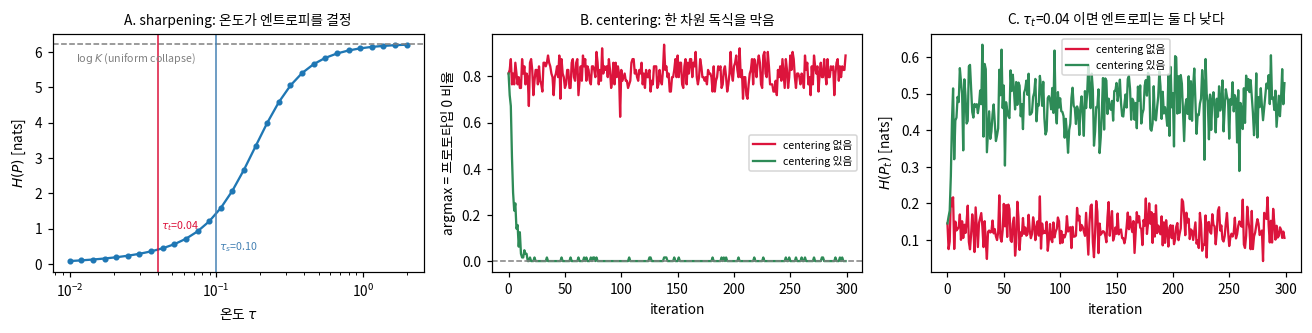

centering 없음: 프로토타입 0 독식 비율 0.819
centering 있음: 프로토타입 0 독식 비율 0.003   (uniform 기대값 0.0020)
학습된 center 가 bias 를 흡수했는지: c[0]=2.011 (주입한 bias=2.0), 나머지 평균=-0.000


In [ ]:
K, Bsz, STEPS = 512, 64, 300
g = torch.Generator().manual_seed(0)

# 실험 A: tau_t 가 교사 분포의 엔트로피를 어떻게 조절하나
z = torch.randn(Bsz, K, generator=g) * 0.5
taus = np.logspace(-2, 0.3, 30)
ent = [(-F.softmax(z / t, -1) * F.log_softmax(z / t, -1)).sum(-1).mean().item() for t in taus]

# 실험 B: centering 이 "한 프로토타입 독식"을 막나
bias = torch.zeros(K); bias[0] = 2.0     # 프로토타입 0 이 구조적으로 유리한 상황

def simulate(use_center, tau_t=0.04, m_c=0.9, steps=STEPS):
    gg = torch.Generator().manual_seed(1)
    center, hist_dom, hist_ent = torch.zeros(1, K), [], []
    for _ in range(steps):
        zt = torch.randn(Bsz, K, generator=gg) * 0.5 + bias
        logits = zt - center if use_center else zt
        p = F.softmax(logits / tau_t, dim=-1)
        hist_dom.append((p.argmax(-1) == 0).float().mean().item())
        hist_ent.append((-(p * p.clamp_min(1e-12).log()).sum(-1)).mean().item())
        center = m_c * center + (1 - m_c) * zt.mean(0, keepdim=True)   # EMA
    return np.array(hist_dom), np.array(hist_ent), center

dom_on, ent_on, c_on = simulate(True)
dom_off, ent_off, _ = simulate(False)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.1))

axes[0].semilogx(taus, ent, "-o", ms=3)
axes[0].axhline(math.log(K), ls="--", c="gray", lw=1)
axes[0].text(0.011, math.log(K) - 0.5, r"$\log K$ (uniform collapse)", fontsize=7, c="gray")
axes[0].axvline(0.04, c="crimson", lw=1); axes[0].axvline(0.1, c="steelblue", lw=1)
axes[0].text(0.042, 1.0, r"$\tau_t$=0.04", fontsize=7, c="crimson")
axes[0].text(0.105, 0.4, r"$\tau_s$=0.10", fontsize=7, c="steelblue")
axes[0].set_xlabel(r"온도 $\tau$"); axes[0].set_ylabel(r"$H(P)$ [nats]")
axes[0].set_title("A. sharpening: 온도가 엔트로피를 결정", fontsize=9)

axes[1].plot(dom_off, label="centering 없음", c="crimson")
axes[1].plot(dom_on, label="centering 있음", c="seagreen")
axes[1].axhline(1 / K, ls="--", c="gray", lw=1)
axes[1].set_xlabel("iteration"); axes[1].set_ylabel("argmax = 프로토타입 0 비율")
axes[1].set_title("B. centering: 한 차원 독식을 막음", fontsize=9)
axes[1].legend(fontsize=7)

axes[2].plot(ent_off, c="crimson", label="centering 없음")
axes[2].plot(ent_on, c="seagreen", label="centering 있음")
axes[2].set_xlabel("iteration"); axes[2].set_ylabel(r"$H(P_t)$ [nats]")
axes[2].set_title(r"C. $\tau_t$=0.04 이면 엔트로피는 둘 다 낮다", fontsize=9)
axes[2].legend(fontsize=7)

fig.tight_layout(); plt.show()

print(f"centering 없음: 프로토타입 0 독식 비율 {dom_off[-50:].mean():.3f}")
print(f"centering 있음: 프로토타입 0 독식 비율 {dom_on[-50:].mean():.3f}"
      f"   (uniform 기대값 {1/K:.4f})")
print(f"학습된 center 가 bias 를 흡수했는지: c[0]={c_on[0,0]:.3f} (주입한 bias=2.0), "
      f"나머지 평균={c_on[0,1:].mean():.3f}")

 읽는 법:

 - **패널 A** — $\tau_t$ 만으로 교사 엔트로피가 $0$ 과 $\log K$ 사이 어디든 갈 수 있다.
   $\tau_t = 0.04 < \tau_s = 0.1$ 이라는 부등호가 "교사가 학생보다 확신에 차 있다"를 보장하고,
   이것이 학습 신호를 만든다. 둘이 같으면 신호가 사라진다.
 - **패널 B** — centering이 없으면 유리한 프로토타입 하나가 배치를 독식한다(붕괴).
   center가 그 편향을 EMA로 흡수해 빼주면 argmax가 흩어진다.
 - **패널 C** — centering은 **엔트로피를 올리지 않는다**. 즉 두 장치는 서로를 대체하지 못한다.
   centering은 "어떤 프로토타입이 뽑히나"의 균형, sharpening은 "얼마나 확신하나"를 담당한다.

 ## 8. 스케줄 4종

 `utils.cosine_scheduler` 는 학습 **전에** iteration 길이의 numpy 배열을 통째로 만들고,
 루프에서 `schedule[it]` 로 조회한다. 스케줄러에 상태가 없으므로 **resume이 자동으로 정확**하다.

 $$
 v_t =
 \begin{cases}
 \dfrac{t}{T_w}\, v_{\text{base}} & t < T_w \quad \text{(linear warmup)}\\[6pt]
 v_{\text{final}} + \dfrac{1}{2}\big(v_{\text{base}} - v_{\text{final}}\big)
 \Big(1 + \cos\dfrac{\pi (t - T_w)}{T - T_w}\Big) & t \ge T_w
 \end{cases}
 $$

 | 스케줄 | 시작 → 끝 | 방향 | 왜 |
 |---|---|---|---|
 | learning rate | $0 \to \texttt{lr} \to 10^{-6}$ | warmup 후 감소 | 표준 |
 | weight decay | $0.04 \to 0.4$ | **증가** | 초기엔 자유 탐색, 후반에 표현 압축 |
 | teacher momentum $m$ | $0.996 \to 1.0$ | 증가 | 교사를 점점 얼려 타겟을 안정화 |
 | teacher temp $\tau_t$ | $0.04 \to \texttt{teacher\_temp}$ | linear (warmup만) | 초기 고온은 불안정 |

 learning rate에는 **linear scaling rule** 이 먼저 적용된다:

 $$
 \texttt{lr}_{\text{eff}} = 0.0005 \times \frac{\texttt{batch\_size\_per\_gpu} \times \texttt{world\_size}}{256}
 $$

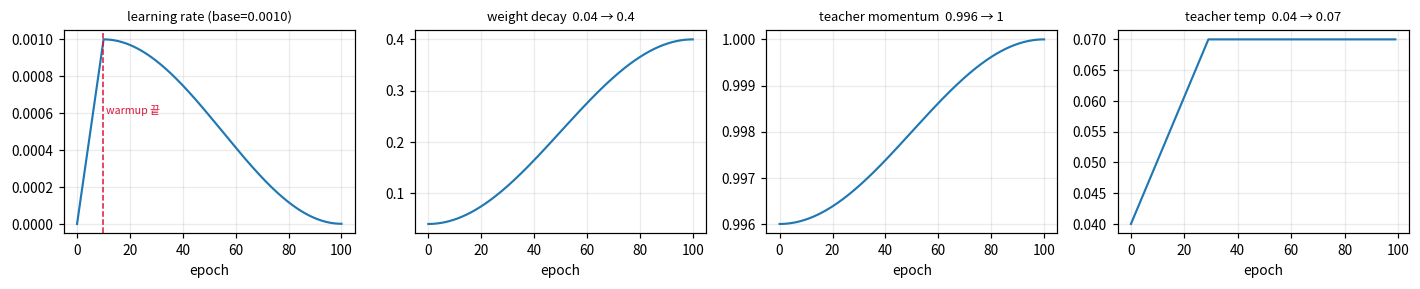

len(lr_schedule) = 125100 = epochs x niter_per_ep = 100 x 1251
lr : 0.00e+00 → 최대 1.00e-03 (it=12509) → 1.00e-06
wd : 0.040 → 0.400   (일반적 스케줄과 반대로 '증가')
m  : 0.9960 → 1.0000


In [ ]:
EPOCHS, NITER = 100, 1251          # ImageNet / batch 1024 근사
lr_base = 0.0005 * (64 * 8) / 256.  # batch 64/GPU x 8 GPU

lr_sched = utils.cosine_scheduler(lr_base, 1e-6, EPOCHS, NITER, warmup_epochs=10)
wd_sched = utils.cosine_scheduler(0.04, 0.4, EPOCHS, NITER)
mom_sched = utils.cosine_scheduler(0.996, 1.0, EPOCHS, NITER)
tt_sched = np.concatenate([np.linspace(0.04, 0.07, 30), np.ones(EPOCHS - 30) * 0.07])

ep = np.arange(EPOCHS * NITER) / NITER
fig, ax = plt.subplots(1, 4, figsize=(13, 2.7))
for a, (y, name, xs) in zip(ax, [
        (lr_sched, f"learning rate (base={lr_base:.4f})", ep),
        (wd_sched, "weight decay  0.04 → 0.4", ep),
        (mom_sched, "teacher momentum  0.996 → 1", ep),
        (tt_sched, "teacher temp  0.04 → 0.07", np.arange(EPOCHS))]):
    a.plot(xs, y, lw=1.4)
    a.set_title(name, fontsize=8.5); a.set_xlabel("epoch"); a.grid(alpha=.25)
ax[0].axvline(10, ls="--", c="crimson", lw=1)
ax[0].text(11, lr_base * .6, "warmup 끝", fontsize=7, c="crimson")
fig.tight_layout(); plt.show()

print(f"len(lr_schedule) = {len(lr_sched)} = epochs x niter_per_ep = {EPOCHS} x {NITER}")
print(f"lr : {lr_sched[0]:.2e} → 최대 {lr_sched.max():.2e} (it={lr_sched.argmax()}) → {lr_sched[-1]:.2e}")
print(f"wd : {wd_sched[0]:.3f} → {wd_sched[-1]:.3f}   (일반적 스케줄과 반대로 '증가')")
print(f"m  : {mom_sched[0]:.4f} → {mom_sched[-1]:.4f}")

 > **함정**: `cosine_scheduler` 마지막 줄이
 > `assert len(schedule) == epochs * niter_per_ep` 다.
 > `warmup_epochs`(기본 10) $>$ `epochs` 면 `iters` 가 음수 길이가 되어 여기서 죽는다.
 > 짧게 스모크 테스트할 땐 `--warmup_epochs 0` 을 반드시 준다
 > ([utils.py:197](../utils.py#L197)).

 ## 9. EMA teacher 갱신

 $$
 \theta_t \leftarrow m\,\theta_t + (1 - m)\,\theta_s,
 \qquad m: 0.996 \nearrow 1.0
 $$

 이는 학생 궤적에 대한 지수 이동평균이므로, 교사는 대략
 **최근 $\tau_{\text{eff}} = \dfrac{1}{1-m}$ iteration** 의 학생을 평균한 모델이다.

 $m \to 1$ 이 되면 교사는 사실상 얼어붙고, 타겟이 고정되어 후반 학습이 안정된다.
 `param_k.data.mul_(m).add_((1 - m) * param_q.detach().data)` — in-place, `no_grad` 안에서 수행.

m        1/(1-m) [iter]   ~epoch (niter=1251)
0.99              100         0.08
0.996             250         0.20
0.999            1000         0.80
0.9999          10000         7.99
0.99999        100000        79.94


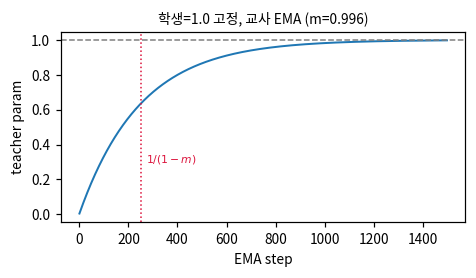


249 step 후 교사값 = 0.6329  (1-1/e = 0.6321)


In [ ]:
print("m        1/(1-m) [iter]   ~epoch (niter=1251)")
for m in [0.99, 0.996, 0.999, 0.9999, 0.99999]:
    print(f"{m:<8} {1/(1-m):>12.0f}   {1/(1-m)/1251:>10.2f}")

# ── 수치로 확인: 학생 파라미터 하나를 바꾸고 EMA 를 돌려 본다
s_p = student.head.mlp[0].weight
t_p = teacher.head.mlp[0].weight
with torch.no_grad():
    s_p.fill_(1.0); t_p.fill_(0.0)

m = 0.996
traj = []
with torch.no_grad():
    for _ in range(1500):
        t_p.data.mul_(m).add_((1 - m) * s_p.detach().data)
        traj.append(t_p[0, 0].item())

plt.figure(figsize=(4.4, 2.6))
plt.plot(traj, lw=1.3)
plt.axhline(1.0, ls="--", c="gray", lw=1)
plt.axvline(1 / (1 - m), ls=":", c="crimson", lw=1)
plt.text(1 / (1 - m) + 20, 0.3, r"$1/(1-m)$", fontsize=7, c="crimson")
plt.xlabel("EMA step"); plt.ylabel("teacher param")
plt.title(f"학생=1.0 고정, 교사 EMA (m={m})", fontsize=9)
plt.tight_layout(); plt.show()

print(f"\n{int(1/(1-m))} step 후 교사값 = {traj[int(1/(1-m))]:.4f}  (1-1/e = {1-1/math.e:.4f})")
student, teacher, _ = build_pair()      # 실험으로 망친 가중치 되돌리기

 ## 10. 학습 1 iteration 완전 해부

 `train_one_epoch` 의 한 스텝은 정확히 이 순서다.

 1. **글로벌 iteration 계산**: `it = len(data_loader) * epoch + it`
 2. **스케줄 주입**: `param_group["lr"] = lr_schedule[it]`,
    weight decay는 **0번 param_group에만** (bias·Norm은 wd 제외 — `get_params_groups`)
 3. crop 리스트를 GPU로
 4. `teacher(images[:2])` — global 2개만, `no_grad` 아님에 주의(모듈 파라미터가 requires_grad=False)
 5. `student(images)` — 전부
 6. `dino_loss(student_output, teacher_output, epoch)`
 7. **NaN 가드**: `math.isfinite(loss.item())` 실패 → `sys.exit(1)`
 8. `backward` (AMP면 `fp16_scaler.scale(loss).backward()`)
 9. **`clip_gradients`** — 주의: `torch.nn.utils.clip_grad_norm_` 과 **다르다**.
    전체 글로벌 노름이 아니라 **파라미터 텐서마다 개별로** 클리핑한다:

    $$
    g_p \leftarrow g_p \cdot \min\!\left(1,\ \frac{\texttt{clip}}{\lVert g_p \rVert_2 + \varepsilon}\right)
    \quad \text{for each } p
    $$

 10. **`cancel_gradients_last_layer`** — `epoch < freeze_last_layer` 면 이름에 `last_layer` 가 든
     파라미터의 grad를 `None` 으로
 11. `optimizer.step()`
 12. **EMA teacher 갱신**

 아래 셀이 이 12단계를 그대로 실행하며 중간값을 찍는다.

In [ ]:
BATCH = 8
loader = torch.utils.data.DataLoader(
    dataset, batch_size=BATCH, shuffle=True, num_workers=2,
    pin_memory=(DEVICE == "cuda"), drop_last=True)

student, teacher, _ = build_pair()
dino_loss = DINOLoss(OUT_DIM, 2 + 8, 0.04, 0.04, 0, NEPOCHS).to(DEVICE)

# 2) param group: 0번만 정규화 대상
params_groups = utils.get_params_groups(student)
optimizer = torch.optim.AdamW(params_groups)
print(f"param_groups: [0] regularized {len(params_groups[0]['params'])} 텐서, "
      f"[1] not-regularized {len(params_groups[1]['params'])} 텐서 (bias/Norm)")

niter = len(loader)
lr_s = utils.cosine_scheduler(0.0005 * BATCH / 256., 1e-6, NEPOCHS, niter, warmup_epochs=0)
wd_s = utils.cosine_scheduler(0.04, 0.4, NEPOCHS, niter)
mo_s = utils.cosine_scheduler(0.996, 1.0, NEPOCHS, niter)

images, _labels_ignored = next(iter(loader))     # ← 레이블은 버린다
epoch, it = 0, 0
gi = niter * epoch + it                                                    # 1)

for i, pg in enumerate(optimizer.param_groups):                            # 2)
    pg["lr"] = lr_s[gi]
    if i == 0:
        pg["weight_decay"] = wd_s[gi]

images = [im.to(DEVICE, non_blocking=True) for im in images]               # 3)
teacher_output = teacher(images[:2])                                       # 4)
student_output = student(images)                                           # 5)
loss = dino_loss(student_output, teacher_output, epoch)                     # 6)
assert math.isfinite(loss.item())                                          # 7)

print(f"\nit={gi}  lr={lr_s[gi]:.3e}  wd={wd_s[gi]:.4f}  m={mo_s[gi]:.5f}")
print(f"teacher_output {tuple(teacher_output.shape)} / student_output {tuple(student_output.shape)}")
print(f"loss = {loss.item():.4f}   (참고: -log(1/K) = {math.log(OUT_DIM):.4f})")

optimizer.zero_grad()
loss.backward()                                                            # 8)

before = {n: p.grad.norm().item() for n, p in student.named_parameters() if p.grad is not None}
norms = utils.clip_gradients(student, clip=3.0)                            # 9)
after = {n: p.grad.norm().item() for n, p in student.named_parameters() if p.grad is not None}
clipped = [n for n in before if after[n] < before[n] - 1e-9]
print(f"\ngrad 텐서 {len(before)}개 중 클리핑된 것: {len(clipped)}개 "
      f"(최대 노름 {max(before.values()):.3f} → {max(after.values()):.3f})")

utils.cancel_gradients_last_layer(epoch, student, freeze_last_layer=1)     # 10)
ll = dict(student.named_parameters())["head.last_layer.weight_v"]
print(f"epoch={epoch} < freeze_last_layer=1  →  last_layer.weight_v.grad = {ll.grad}")

optimizer.step()                                                           # 11)

with torch.no_grad():                                                      # 12)
    m = mo_s[gi]
    d0 = max((ps - pt).abs().max().item()
             for ps, pt in zip(student.parameters(), teacher.parameters()))
    for pq, pk in zip(student.parameters(), teacher.parameters()):
        pk.data.mul_(m).add_((1 - m) * pq.detach().data)
    d1 = max((ps - pt).abs().max().item()
             for ps, pt in zip(student.parameters(), teacher.parameters()))
print(f"\nEMA 전 max|θs-θt| = {d0:.3e}  →  후 {d1:.3e}  (m={m:.5f} 이라 교사는 아주 조금만 따라감)")

param_groups: [0] regularized 55 텐서, [1] not-regularized 102 텐서 (bias/Norm)

it=0  lr=1.563e-05  wd=0.0400  m=0.99600
teacher_output (16, 4096) / student_output (80, 4096)
loss = 7.9836   (참고: -log(1/K) = 8.3178)

grad 텐서 157개 중 클리핑된 것: 0개 (최대 노름 1.094 → 1.094)
epoch=0 < freeze_last_layer=1  →  last_layer.weight_v.grad = None

EMA 전 max|θs-θt| = 1.568e-05  →  후 1.562e-05  (m=0.99600 이라 교사는 아주 조금만 따라감)


 > `train_one_epoch` 은 `student.module.parameters()` 를 쓴다 — 실제 학습에서 student가
 > **항상 DDP로 감싸져 있기** 때문이다. 이 노트북은 DDP 없이 돌리므로 `.module` 을 뺐다.
 > 반대로 teacher는 BatchNorm이 있을 때만 DDP로 감싸고(`has_batchnorms`), ViT는 BN이 없어
 > `teacher_without_ddp = teacher` 가 된다.

 ## 11. 미니 학습 루프 + 붕괴 실험

 `main_dino.py` 의 사전학습 루프에는 **검증이 전혀 없다**. loss / lr / wd 만 로깅한다.
 그리고 이게 중요한데 — **loss 값은 표현 품질과 상관되지 않는다.**
 붕괴는 loss를 *더 잘* 낮춘다.

 그래서 학습을 지켜볼 때 실제로 봐야 하는 것은 loss가 아니라 교사 분포의 모양이다.

 | 진단량 | 정의 | 붕괴 신호 |
 |---|---|---|
 | 교사 엔트로피 | $H(P_t) = -\sum_k P_t(k)\log P_t(k)$ | $\to 0$ 또는 $\to \log K$ |
 | 교사 top-1 확률 | $\max_k P_t(k)$ | $\to 1$ |
 | argmax 다양성 | 배치 내 서로 다른 argmax 프로토타입 수 | $\to 1$ |
 | center 노름 | $\lVert c \rVert_2$ | 발산 |

 아래에서 **같은 루프를 세 설정으로** 돌려 §7의 주장을 실제 모델로 확인한다.

 | 설정 | centering | $\tau_t$ | 예상 |
 |---|---|---|---|
 | DINO | O | 0.04 | 건강 |
 | centering 제거 | X | 0.04 | 단일 프로토타입 쪽으로 붕괴 |
 | sharpening 제거 | O | 0.10 $(= \tau_s)$ | uniform 붕괴 |

In [ ]:
BATCH, NEPOCHS = 8, 3
loader = torch.utils.data.DataLoader(
    dataset, batch_size=BATCH, shuffle=True, num_workers=4,
    pin_memory=(DEVICE == "cuda"), drop_last=True)
niter = len(loader)

def run_mini(use_center=True, teacher_temp=0.04, epochs=NEPOCHS, seed=0):
    # train_one_epoch 과 같은 순서. DDP 없음, teacher_temp 는 warmup 없이 고정.
    utils.fix_random_seeds(seed)
    st, te, _ = build_pair()
    dl_ = DINOLoss(OUT_DIM, 2 + 8, teacher_temp, teacher_temp, 0, epochs).to(DEVICE)
    if not use_center:
        dl_.update_center = lambda *a, **k: None      # center 를 0 으로 고정 = centering 제거
    opt = torch.optim.AdamW(utils.get_params_groups(st))
    lr_s = utils.cosine_scheduler(0.0005 * BATCH / 256., 1e-6, epochs, niter, warmup_epochs=0)
    wd_s = utils.cosine_scheduler(0.04, 0.4, epochs, niter)
    mo_s = utils.cosine_scheduler(0.996, 1.0, epochs, niter)
    scaler = torch.cuda.amp.GradScaler() if DEVICE == "cuda" else None

    h = {k: [] for k in ["loss", "H_t", "top1", "uniq", "cnorm"]}
    for epoch in range(epochs):
        for it, (images, _) in enumerate(loader):        # ← 레이블은 버린다
            gi = niter * epoch + it                                          # 1)
            for i, pg in enumerate(opt.param_groups):                        # 2)
                pg["lr"] = lr_s[gi]
                if i == 0:
                    pg["weight_decay"] = wd_s[gi]
            images = [im.to(DEVICE, non_blocking=True) for im in images]     # 3)

            with torch.cuda.amp.autocast(scaler is not None):
                teacher_output = te(images[:2])                              # 4)
                student_output = st(images)                                  # 5)
                loss = dl_(student_output, teacher_output, epoch)            # 6)
            if not math.isfinite(loss.item()):                               # 7)
                raise RuntimeError("loss NaN — 실제 코드는 sys.exit(1)")

            opt.zero_grad()
            if scaler is None:
                loss.backward()                                              # 8)
                utils.clip_gradients(st, 3.0)                                # 9)
                utils.cancel_gradients_last_layer(epoch, st, 1)              # 10)
                opt.step()                                                   # 11)
            else:
                scaler.scale(loss).backward()
                scaler.unscale_(opt)
                utils.clip_gradients(st, 3.0)
                utils.cancel_gradients_last_layer(epoch, st, 1)
                scaler.step(opt)
                scaler.update()

            with torch.no_grad():
                m = mo_s[gi]                                                 # 12)
                for pq, pk in zip(st.parameters(), te.parameters()):
                    pk.data.mul_(m).add_((1 - m) * pq.detach().data)

                p_t = F.softmax((teacher_output.float() - dl_.center) / teacher_temp, dim=-1)
                h["loss"].append(loss.item())
                h["H_t"].append((-(p_t * p_t.clamp_min(1e-12).log()).sum(-1)).mean().item())
                h["top1"].append(p_t.max(-1).values.mean().item())
                h["uniq"].append(p_t.argmax(-1).unique().numel())
                h["cnorm"].append(dl_.center.norm().item())
    return h, st, te

t0 = time.time()
runs = {}
runs["DINO (center + sharpen)"] = run_mini(True, 0.04)
runs["centering 제거"] = run_mini(False, 0.04)
runs["sharpening 제거 (tau_t=tau_s)"] = run_mini(True, 0.10)
print(f"3 x ({NEPOCHS} epoch x {niter} iter) = {3*NEPOCHS*niter} step, {time.time()-t0:.0f}s\n")

hist, student, teacher = runs["DINO (center + sharpen)"]   # 이후 절에서 재사용

logK = math.log(OUT_DIM)
print(f"{'설정':32s} {'loss 처음→끝':>20s} {'H(P_t) 처음→끝':>20s} {'top1 처음→끝':>18s}")
for name, (h, _, _) in runs.items():
    print(f"{name:32s} {h['loss'][0]:8.3f} →{np.mean(h['loss'][-20:]):8.3f} "
          f"{h['H_t'][0]:9.3f} →{np.mean(h['H_t'][-20:]):8.3f} "
          f"{h['top1'][0]:8.3f} →{np.mean(h['top1'][-20:]):6.3f}")
print(f"\nlog K = {logK:.3f}  (uniform 기준),  1/K = {1/OUT_DIM:.5f}")

3 x (3 epoch x 75 iter) = 675 step, 60s

설정                                          loss 처음→끝          H(P_t) 처음→끝          top1 처음→끝
DINO (center + sharpen)             8.076 →   8.114     7.212 →   7.408    0.018 → 0.018
centering 제거                        8.076 →   6.628     7.151 →   5.862    0.020 → 0.192
sharpening 제거 (tau_t=tau_s)         8.332 →   8.331     8.134 →   8.188    0.002 → 0.001

log K = 8.318  (uniform 기준),  1/K = 0.00024


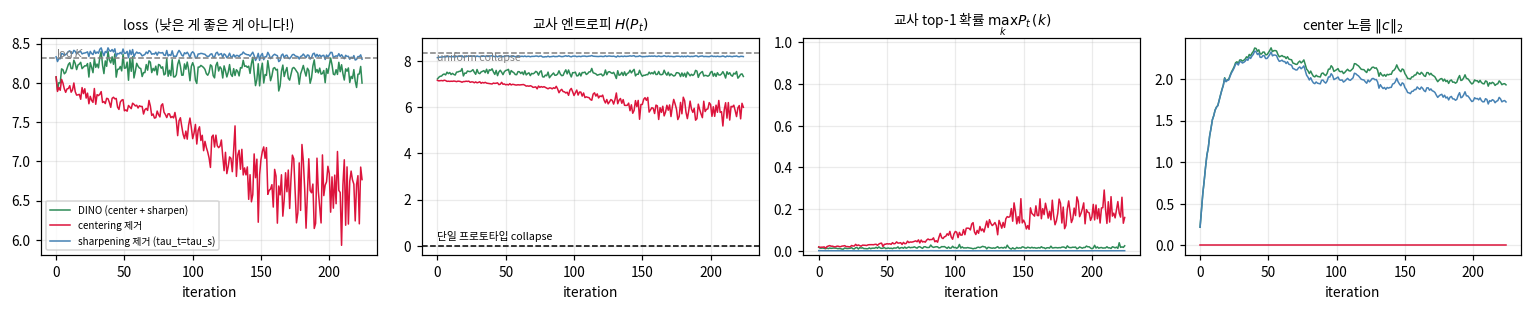

DINO (center + sharpen)          argmax 다양성(배치 16행):   9 →   8
centering 제거                     argmax 다양성(배치 16행):   9 →   5
sharpening 제거 (tau_t=tau_s)      argmax 다양성(배치 16행):   9 →   9


In [ ]:
COLORS = {"DINO (center + sharpen)": "seagreen",
          "centering 제거": "crimson",
          "sharpening 제거 (tau_t=tau_s)": "steelblue"}

fig, ax = plt.subplots(1, 4, figsize=(14, 2.9))
for name, (h, _, _) in runs.items():
    c = COLORS[name]
    ax[0].plot(h["loss"], lw=1, c=c, label=name)
    ax[1].plot(h["H_t"], lw=1, c=c)
    ax[2].plot(h["top1"], lw=1, c=c)
    ax[3].plot(h["cnorm"], lw=1, c=c)

ax[0].axhline(logK, ls="--", c="gray", lw=1)
ax[0].text(0, logK * 1.002, r"$\log K$", fontsize=7, c="gray")
ax[0].set_title("loss  (낮은 게 좋은 게 아니다!)", fontsize=9)
ax[0].legend(fontsize=6.5, loc="lower left")

ax[1].axhline(logK, ls="--", c="gray", lw=1)
ax[1].text(0, logK * 0.96, "uniform collapse", fontsize=7, c="gray")
ax[1].axhline(0, ls="--", c="k", lw=1)
ax[1].text(0, 0.25, "단일 프로토타입 collapse", fontsize=7)
ax[1].set_ylim(-0.4, logK * 1.08)
ax[1].set_title(r"교사 엔트로피 $H(P_t)$", fontsize=9)

ax[2].set_ylim(-0.02, 1.02)
ax[2].set_title(r"교사 top-1 확률 $\max_k P_t(k)$", fontsize=9)
ax[3].set_title(r"center 노름 $\|c\|_2$", fontsize=9)
for a in ax:
    a.set_xlabel("iteration"); a.grid(alpha=.25)
fig.tight_layout(); plt.show()

for name, (h, _, _) in runs.items():
    print(f"{name:32s} argmax 다양성(배치 {2*BATCH}행): {h['uniq'][0]:3d} → {h['uniq'][-1]:3d}")

 ### 읽는 법

 **centering 제거** — loss가 세 설정 중 **가장 많이 내려간다**. 그런데 동시에
 $H(P_t)$ 가 내려가고 top-1 확률이 올라가고 argmax 다양성이 줄어든다.
 즉 loss 감소분은 두 view를 정렬해서 얻은 게 아니라
 $H(P_t,P_s) = H(P_t) + D_{\mathrm{KL}}(P_t\|P_s)$ 의 **첫 항을 깎아서** 얻은 것이다.
 **이게 붕괴다.** 사전학습 로그의 loss만 보고 있으면 이걸 "학습이 잘 된다"로 오독한다.

 **sharpening 제거** ($\tau_t = \tau_s = 0.1$) — loss가 $\log K \approx 8.32$ 에서 꼼짝하지 않는다.
 교사와 학생 분포가 같은 온도라 gradient가 사실상 사라진 uniform 평탄면이다.

 **DINO** — loss는 $\log K$ 근처에 머물지만 $H(P_t)$ 는 $\log K$ 보다 확실히 낮은 값에서
 안정되고, top-1 확률도 $1/K$ 보다 크지만 1에서 멀다. 두 붕괴 영역 사이에 **매달려 있는** 상태다.

 ### 이 구간에서 표현이 학습되지는 않는다

 수백 step으로는 아무것도 안 배운다. DINO의 loss는 학습 초반 오랫동안 $\log K$ 근처에 머물고,
 구조는 그 평탄면 위에서 서서히 생긴다 — ImageNet ViT-S/16 8 GPU 기준 100 epoch에 **약 1.75일**.
 여기서 확인한 것은 "파이프라인이 돌고, 진단량이 붕괴 영역으로 떨어지지 않는다" 뿐이다.
 실제 실행 명령은 [SAMPLES.md](../SAMPLES.md) §3 참고.

 ## 12. 표현 품질 확인: k-NN

 사전학습 루프에는 검증이 없으므로, 표현 품질은 **따로** 재야 한다.
 `eval_knn.py` 는 학습 파라미터가 **0개**다 — backbone을 얼린 뒤 CLS 특징만 뽑아
 코사인 유사도로 이웃을 찾는다.

 $$
 \hat{y}(x) = \arg\max_{c}\ \sum_{i \in \mathcal{N}_k(x)}
 \mathbb{1}[y_i = c]\cdot \exp\!\left(\frac{\cos(z_x, z_i)}{T}\right),
 \qquad T = 0.07
 $$

 `eval_knn.py` 는 특징을 `nn.functional.normalize` 로 L2 정규화한 뒤 내적을 쓰므로
 내적 = 코사인 유사도다. head는 여기서 쓰이지 않는다 (버려지는 부분).

In [ ]:
eval_tf = transforms.Compose([
    transforms.Resize(256, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

@torch.no_grad()
def extract(backbone, root, bs=32):
    ds = datasets.ImageFolder(str(root), transform=eval_tf)
    dl = torch.utils.data.DataLoader(ds, batch_size=bs, num_workers=2, shuffle=False)
    feats, labels = [], []
    backbone.eval()
    for xb, yb in dl:
        f = backbone(xb.to(DEVICE))
        feats.append(F.normalize(f.float(), dim=-1, p=2).cpu())
        labels.append(yb)
    return torch.cat(feats), torch.cat(labels), len(ds.classes)

@torch.no_grad()
def knn_top1(ftr, ltr, fte, lte, ncls, k=20, T=0.07):
    # eval_knn.knn_classifier 와 동일 로직 (val<100장에서 죽는 chunk 버그만 제거)
    sim = fte @ ftr.t()
    d, idx = sim.topk(min(k, ftr.shape[0]), dim=-1)
    nb = ltr[idx]
    w = (d / T).exp()
    probs = torch.zeros(fte.shape[0], ncls).scatter_add_(1, nb, w)
    return (probs.argmax(-1) == lte).float().mean().item() * 100

VAL = DATA_ROOT / "val"
if VAL.exists():
    # 랜덤 초기화 백본 (비교 기준)
    rand_bb = vits.__dict__[ARCH](patch_size=PATCH).to(DEVICE)
    for name, bbone in [("random init", rand_bb), ("mini-trained teacher", teacher.backbone)]:
        ftr, ltr, ncls = extract(bbone, DATA_ROOT / "train")
        fte, lte, _ = extract(bbone, VAL)
        acc = knn_top1(ftr, ltr, fte, lte, ncls)
        print(f"{name:22s} 20-NN top1 = {acc:5.2f}%   "
              f"(train {ftr.shape[0]} / val {fte.shape[0]}, {ncls} classes, chance={100/ncls:.1f}%)")
    del rand_bb
else:
    print("val 디렉터리가 없어 건너뜀")

random init            20-NN top1 = 24.00%   (train 600 / val 400, 10 classes, chance=10.0%)
mini-trained teacher   20-NN top1 = 24.00%   (train 600 / val 400, 10 classes, chance=10.0%)


 **이 숫자를 믿지 말 것.** 수십 step 학습한 ViT-Tiny와 랜덤 초기화는 둘 다 chance 근처다.
 의미 있는 비교 대상은 공식 사전학습 가중치다 — [SAMPLES.md](../SAMPLES.md) §4 기준
 CIFAR-10 부분집합(600/400)에서 ViT-S/16 frozen feature가 **20-NN top1 87.0%** 를 낸다.

 > **함정** ([eval_knn.py:149](../eval_knn.py#L149)): 원본 `knn_classifier` 는
 > `imgs_per_chunk = num_test_images // 100` 이라
 > **val 이미지가 100장 미만이면 `ValueError: range() arg 3 must not be zero`** 로 죽는다.
 > 위 셀에서는 그 chunking을 제거했다.

 ## 13. 어텐션은 왜 물체를 찾는가

 DINO의 유명한 결과 — 지도 없이 학습한 ViT의 **[CLS] 토큰 어텐션이 객체 경계를 따라간다**.

 마지막 블록의 어텐션에서 CLS 행만 꺼내면 각 헤드가 어떤 패치를 보는지 나온다:

 $$
 A^{(h)} = \mathrm{softmax}\!\left(\frac{q^{(h)} k^{(h)\top}}{\sqrt{d_h}}\right)
 \in \mathbb{R}^{(1+P)\times(1+P)},
 \qquad a^{(h)} = A^{(h)}[0,\ 1:] \in \mathbb{R}^{P}
 $$

 이를 $\sqrt{P}\times\sqrt{P}$ 로 reshape 후 patch_size 배 업샘플하면 히트맵이 된다.

 왜 이렇게 되는가에 대한 직관: local crop(96px, 면적 5~40%)이 global crop을 예측해야 하므로,
 네트워크는 **부분에서 전체를 식별할 수 있는 단서** = 객체의 판별적 영역에 주의를 몰아야 한다.
 배경은 crop마다 달라져 도움이 안 되고, 객체는 crop 간에 일관된다.

 `Attention.forward` 가 `return x, attn` 으로 **어텐션 맵을 항상 함께 반환**하는 것도
 이 시각화를 위한 의도적 설계다. 대가로 `F.scaled_dot_product_attention`(FlashAttention)을
 쓸 수 없어 $(B, \text{heads}, N, N)$ 행렬이 항상 메모리에 올라간다 — patch 8 + 큰 이미지에서 OOM의 주범.

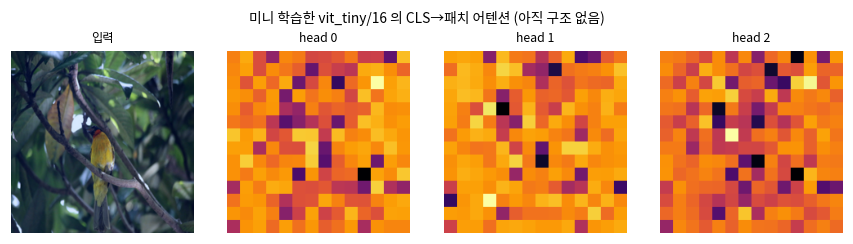

어텐션 텐서 (1, 3, 197, 197)  = (B, heads=3, 1+196, 1+196)

제대로 학습된 가중치로 보려면:
  python visualize_attention.py --arch vit_small --patch_size 8 \
      --image_size 480 480 --threshold 0.6 --output_dir out/dino_attn


In [ ]:
img = eval_tf(raw).unsqueeze(0).to(DEVICE)
w_f = img.shape[-1] // PATCH

with torch.no_grad():
    a = teacher.backbone.get_last_selfattention(img)       # (1, heads, 1+P, 1+P)
nh = a.shape[1]
cls_attn = a[0, :, 0, 1:].reshape(nh, w_f, w_f)
cls_attn = F.interpolate(cls_attn.unsqueeze(0), scale_factor=PATCH,
                         mode="nearest")[0].cpu().numpy()

fig, ax = plt.subplots(1, nh + 1, figsize=(2.0 * (nh + 1), 2.2))
ax[0].imshow(denorm(img[0])); ax[0].set_title("입력", fontsize=8); ax[0].axis("off")
for h in range(nh):
    ax[h + 1].imshow(cls_attn[h], cmap="inferno")
    ax[h + 1].set_title(f"head {h}", fontsize=8); ax[h + 1].axis("off")
fig.suptitle(f"미니 학습한 {ARCH}/{PATCH} 의 CLS→패치 어텐션 (아직 구조 없음)", fontsize=9)
fig.tight_layout(); plt.show()

print(f"어텐션 텐서 {tuple(a.shape)}  = (B, heads={nh}, 1+{w_f*w_f}, 1+{w_f*w_f})")
print("\n제대로 학습된 가중치로 보려면:")
print("  python visualize_attention.py --arch vit_small --patch_size 8 \\")
print("      --image_size 480 480 --threshold 0.6 --output_dir out/dino_attn")

 ## 14. 요약 · 함정 · 다음 단계

 ### 학습 과정 한 장 요약

 ```
 ImageFolder (레이블 폐기)
    │
    ├─ DataAugmentationDINO ──▶ [g1(224), g2(224), l1..l8(96)]   비대칭 증강
    │
    ├─ teacher(g1, g2) ──▶ (2B, K) ──┐  centering(-c) + sharpening(τt=0.04) + detach
    │      ▲                          │
    │      │ EMA (m: 0.996↗1.0)      ▼
    ├─ student(전부)  ──▶ (10B, K) ──▶ DINOLoss = mean of 18 cross-entropy terms
    │      │                                        │
    │      └──── AdamW ◀── clip(3.0, per-tensor) ◀──┘ (+ epoch 0 은 last_layer 동결)
    │
    └─ 스케줄 4종: lr(warmup→cos↓) / wd(0.04→0.4↗) / m(0.996→1↗) / τt(0.04→0.07↗)
 ```

 ### 하이퍼파라미터가 하는 일

 | 파라미터 | 기본값 | 역할 | 잘못 주면 |
 |---|---|---|---|
 | `out_dim` $K$ | 65536 | 프로토타입 수 | 작으면 표현력 부족, 크면 head가 백본보다 커짐 |
 | `teacher_temp` $\tau_t$ | 0.04 → 0.07 | sharpening | $\tau_t \ge \tau_s$ 면 학습 신호 소멸 |
 | `student_temp` $\tau_s$ | 0.1 (고정) | 학생 분포 | — |
 | `center_momentum` | 0.9 | centering EMA | 너무 크면 편향 추적 실패 |
 | `momentum_teacher` | 0.996 → 1 | 타겟 안정성 | 작으면 타겟 요동 → 붕괴 |
 | `local_crops_number` | 8 | local-to-global 항 수 | 0이면 multi-crop 무효화 |
 | `freeze_last_layer` | 1 epoch | 초기 안정화 | 0이면 초기 진동 |
 | `clip_grad` | 3.0 | per-tensor 클리핑 | — |
 | `warmup_epochs` | 10 | lr warmup | `> epochs` 면 assert 실패 |

 ### 실전 함정

 1. **`--warmup_epochs 0`** 없이 짧게 돌리면 `utils.cosine_scheduler` assert에서 죽는다.
 2. **`eval_knn.py` 는 val < 100장이면** `range() arg 3 must not be zero` 로 죽는다.
 3. **`eval_linear.py` 는 `output_dir` 을 만들지 않는다** — 미리 `mkdir -p`.
 4. **사전학습에 검증이 없다** → 조기 종료도 best 선택도 불가. loss만 보면 붕괴를 놓친다.
 5. **crop 리스트는 해상도 내림차순** 이어야 `MultiCropWrapper` 그룹핑이 이득을 낸다.
 6. **`DINOLoss` 는 프로세스 그룹 필수** (`update_center` 의 `all_reduce`).
 7. **`eval_linear.py` 의 저장 체크포인트는 best가 아니라 last** 다.

 ### 다음 단계

 ```bash
 # 스모크 테스트 (수 초)
 python main_dino.py --arch vit_tiny --patch_size 16 \
     --data_path out/dino_tiny/train --output_dir out/dino_train \
     --epochs 2 --warmup_epochs 0 --batch_size_per_gpu 8 --local_crops_number 4

 # 실제 학습 (8 GPU 1노드)
 python -m torch.distributed.launch --nproc_per_node=8 main_dino.py \
     --arch vit_small --data_path /path/to/imagenet/train --output_dir /path/to/save
 ```

 - 실행 샘플 전체: [SAMPLES.md](../SAMPLES.md)
 - ML 심층 분석(파라미터 실측, 데이터 흐름 다이어그램): [docs/analysis/2026-09-04-ml-analysis.md](../docs/analysis/2026-09-04-ml-analysis.md)
 - 구조·의존성 분석: [docs/analysis/2026-09-04-full-analysis.md](../docs/analysis/2026-09-04-full-analysis.md)
 - 논문: [arXiv:2104.14294](https://arxiv.org/abs/2104.14294)

In [ ]:
if dist.is_initialized():
    dist.destroy_process_group()
    print("프로세스 그룹 정리 완료")

프로세스 그룹 정리 완료
